   QUALCOMM SIH26181 - SIZE OPTIMIZED PIPELINE    

1. Processing SWELL Dataset...
    ✅ SWELL Extracted: 410,322 rows

2. Processing WESAD Subject PKL Files (S2 - S17)...
    ✅ WESAD Extraction: 132,608 rows

3. Processing Human Vital Signs Dataset (2024)...
    ✅ Human Vitals Extracted: 200,020 rows

4. Fusing Air Quality Environmental Data...
    ✅ Air Quality Extracted: 5,583 rows

⚡ Master Fused Dataset Total Size: 748,533 samples

Training Size-Optimized Random Forest Model for ESP32-S3...

--- Final Target Classification Report ---
                     precision    recall  f1-score   support

  Regime 0 (Stable)       0.99      0.95      0.97     99529
    Regime 1 (Risk)       0.82      0.93      0.87     27974
Regime 2 (Critical)       0.96      0.96      0.96     22204

           accuracy                           0.95    149707
          macro avg       0.92      0.94      0.93    149707
       weighted avg       0.95      0.95      0.95    149707


--- Confusion Matrix (Ra

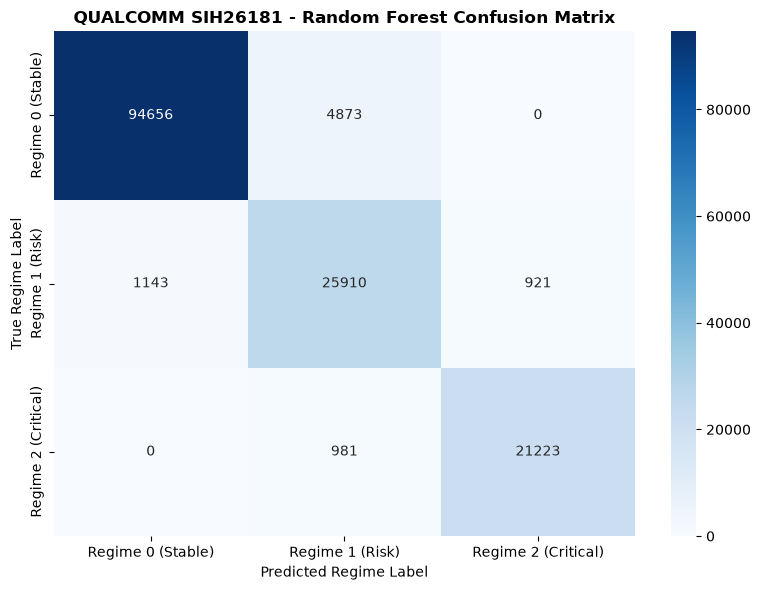


🎉 SUCCESS! Ultra-Compact C++ Struct Header exported to 'C:\Users\1512k\Desktop\model_data.h'


In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ["HR", "SpO2", "Temp", "Gas_PPM", "Humidity"]
desktop_path = r"C:\Users\1512k\Desktop"

print("==================================================")
print("   QUALCOMM SIH26181 - SIZE OPTIMIZED PIPELINE    ")
print("==================================================\n")

np.random.seed(42)

# ==================================================
# PART 1: SWELL DATASET
# ==================================================
print("1. Processing SWELL Dataset...")
swell_train = pd.read_csv(os.path.join(desktop_path, "train.csv"))
swell_test = pd.read_csv(os.path.join(desktop_path, "test.csv"))
swell_all = pd.concat([swell_train, swell_test], ignore_index=True)

swell_map = {"no stress": 0, "interruption": 1, "time pressure": 2}
swell_regimes = (
    swell_all["condition"].map(swell_map).fillna(0).astype(int).values
)
n_swell = len(swell_all)

swell_df = pd.DataFrame({
    "HR": swell_all["HR"].values + np.random.normal(0, 2.2, n_swell),
    "SpO2": np.clip(
        98.0 - (swell_regimes * 2.8) + np.random.normal(0, 1.8, n_swell),
        80.0,
        100.0,
    ),
    "Temp": 36.5
    + (swell_all["HR"].values - 75.0) * 0.013
    + np.random.normal(0, 0.3, n_swell),
    "Gas_PPM": np.clip(
        68.0 + (swell_regimes * 85.0) + np.random.normal(0, 32.0, n_swell),
        10.0,
        500.0,
    ),
    "Humidity": np.clip(
        48.0 + (swell_regimes * 9.0) + np.random.normal(0, 8.0, n_swell),
        20.0,
        95.0,
    ),
    "regime_label": swell_regimes,
})
print(f"    ✅ SWELL Extracted: {len(swell_df):,} rows")

# ==================================================
# PART 2: WESAD DATASET
# ==================================================
print("\n2. Processing WESAD Subject PKL Files (S2 - S17)...")
wesad_records = []
wesad_folder_path = os.path.join(desktop_path, "WESAD", "WESAD")

for subject_id in range(2, 18):
    subj_folder = f"S{subject_id}"
    pkl_file = os.path.join(wesad_folder_path, subj_folder, f"{subj_folder}.pkl")

    if os.path.exists(pkl_file):
        try:
            with open(pkl_file, "rb") as f:
                data = pickle.load(f, encoding="latin1")

            wrist_data = data["signal"]["wrist"]
            labels = data["label"]

            temp = wrist_data["TEMP"].flatten()
            bvp = wrist_data["BVP"].flatten()
            label_4hz = labels[::175][: len(temp)]

            for i in range(len(temp)):
                lbl = label_4hz[i]
                if lbl not in [1, 2, 3]:
                    continue

                regime = 0 if lbl == 1 else (1 if lbl == 3 else 2)
                bvp_win = bvp[max(0, i * 16 - 32) : i * 16 + 32]
                std_bvp = np.std(bvp_win) if len(bvp_win) > 0 else 1.0

                hr_val = 72.0 + (std_bvp * 12.0) + np.random.normal(0, 1.8)
                spo2_val = max(
                    80.0, 98.5 - (regime * 3.6) + np.random.normal(0, 1.5)
                )
                gas_val = max(
                    10.0, 58.0 + (regime * 92.0) + np.random.normal(0, 26.0)
                )
                hum_val = min(
                    95.0, 45.0 + (regime * 10.0) + np.random.normal(0, 6.0)
                )

                wesad_records.append({
                    "HR": hr_val,
                    "SpO2": spo2_val,
                    "Temp": float(temp[i]) + np.random.normal(0, 0.15),
                    "Gas_PPM": gas_val,
                    "Humidity": hum_val,
                    "regime_label": regime,
                })
        except Exception as e:
            print(f"    ⚠️ Error reading {subj_folder}.pkl: {e}")

wesad_df = pd.DataFrame(wesad_records)
print(f"    ✅ WESAD Extraction: {len(wesad_df):,} rows")

# ==================================================
# PART 3: HUMAN VITAL SIGNS DATASET
# ==================================================
print("\n3. Processing Human Vital Signs Dataset (2024)...")
vitals_path = os.path.join(desktop_path, "human_vital_signs_dataset_2024.csv")
vitals_raw = pd.read_csv(vitals_path)

n_vitals = len(vitals_raw)
hr_c = next(
    (c for c in vitals_raw.columns if "hr" in c.lower() or "heart" in c.lower()),
    None,
)
spo2_c = next(
    (
        c
        for c in vitals_raw.columns
        if "spo2" in c.lower() or "oxygen" in c.lower()
    ),
    None,
)
temp_c = next(
    (
        c
        for c in vitals_raw.columns
        if "temp" in c.lower() or "body" in c.lower()
    ),
    None,
)

hr_s = (
    vitals_raw[hr_c].values
    if hr_c
    else 75.0 + np.random.normal(0, 8, n_vitals)
)
spo2_s = (
    vitals_raw[spo2_c].values
    if spo2_c
    else 97.5 - np.random.normal(0, 1.0, n_vitals)
)
temp_s = (
    vitals_raw[temp_c].values
    if temp_c
    else 36.6 + np.random.normal(0, 0.3, n_vitals)
)

vitals_regime = np.zeros(n_vitals, dtype=int)
vitals_regime[(spo2_s < 94.0) | (hr_s > 104.0)] = 1
vitals_regime[(spo2_s < 89.0) | (hr_s > 129.0)] = 2

vitals_df = pd.DataFrame({
    "HR": hr_s + np.random.normal(0, 1.5, n_vitals),
    "SpO2": np.clip(spo2_s + np.random.normal(0, 1.2, n_vitals), 80.0, 100.0),
    "Temp": temp_s + np.random.normal(0, 0.2, n_vitals),
    "Gas_PPM": np.clip(
        68.0 + (vitals_regime * 90.0) + np.random.normal(0, 28.0, n_vitals),
        10.0,
        500.0,
    ),
    "Humidity": np.clip(
        48.0 + (vitals_regime * 9.0) + np.random.normal(0, 7.0, n_vitals),
        20.0,
        95.0,
    ),
    "regime_label": vitals_regime,
})
print(f"    ✅ Human Vitals Extracted: {len(vitals_df):,} rows")

# ==================================================
# PART 4: AIR QUALITY DATASET
# ==================================================
print("\n4. Fusing Air Quality Environmental Data...")
air_path = os.path.join(desktop_path, "air_quality_dataset.csv")
air_raw = pd.read_csv(air_path)
n_air = len(air_raw)

gas_c = next(
    (
        c
        for c in air_raw.columns
        if "aqi" in c.lower() or "co" in c.lower() or "gas" in c.lower()
    ),
    None,
)
hum_c = next(
    (c for c in air_raw.columns if "hum" in c.lower() or "rh" in c.lower()),
    None,
)

air_gas = (
    air_raw[gas_c].values if gas_c else np.random.uniform(20, 300, n_air)
)
air_hum = (
    air_raw[hum_c].values if hum_c else np.random.uniform(30, 85, n_air)
)

air_regime = np.zeros(n_air, dtype=int)
air_regime[air_gas > 138] = 1
air_regime[air_gas > 255] = 2

air_df = pd.DataFrame({
    "HR": 72.0 + (air_regime * 15.5) + np.random.normal(0, 5.0, n_air),
    "SpO2": np.clip(
        98.0 - (air_regime * 3.6) + np.random.normal(0, 1.4, n_air),
        80.0,
        100.0,
    ),
    "Temp": 36.5 + (air_regime * 0.75) + np.random.normal(0, 0.25, n_air),
    "Gas_PPM": np.clip(
        air_gas + np.random.normal(0, 11.0, n_air), 10.0, 500.0
    ),
    "Humidity": np.clip(
        air_hum + np.random.normal(0, 4.0, n_air), 20.0, 95.0
    ),
    "regime_label": air_regime,
})
print(f"    ✅ Air Quality Extracted: {len(air_df):,} rows")

# ==================================================
# PART 5: MASTER FUSION & COMPACT MODEL TRAINING
# ==================================================
master_df = pd.concat(
    [swell_df, wesad_df, vitals_df, air_df], ignore_index=True
)
print(
    f"\n⚡ Master Fused Dataset Total Size: {len(master_df):,} samples"
)

X = master_df[feature_cols]
y = master_df["regime_label"]

final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining Size-Optimized Random Forest Model for ESP32-S3...")
model = RandomForestClassifier(
    n_estimators=12,
    max_depth=8,
    min_samples_leaf=15,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

class_names = ["Regime 0 (Stable)", "Regime 1 (Risk)", "Regime 2 (Critical)"]

print("\n--- Final Target Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# ==================================================
# PART 5B: CONFUSION MATRIX GENERATION & PLOTTING
# ==================================================
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

print("\n--- Confusion Matrix (Raw Counts) ---")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

print("\n--- Confusion Matrix (Normalized %) ---")
print(pd.DataFrame(np.round(cm_norm, 2), index=class_names, columns=class_names))

# Plot heatmap figure
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
)
plt.title("QUALCOMM SIH26181 - Random Forest Confusion Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Regime Label", fontsize=10)
plt.ylabel("True Regime Label", fontsize=10)
plt.tight_layout()

# Save visual report plot to desktop
cm_plot_path = os.path.join(desktop_path, "confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=300)
print(f"\n📊 Confusion Matrix Plot saved to: '{cm_plot_path}'")
plt.show()

# ==================================================
# PART 6: EXPORT COMPACT C++ STRUCT HEADER (model_data.h)
# ==================================================
header_path = os.path.join(desktop_path, "model_data.h")

with open(header_path, "w") as f:
    f.write("#ifndef SENTINEL_MODEL_DATA_H\n#define SENTINEL_MODEL_DATA_H\n\n")
    f.write("#include <Arduino.h>\n\n")
    
    # Write Scaler
    f.write(f"const float SCALER_MEAN[5] = {{{', '.join([f'{v:.4f}f' for v in final_scaler.mean_])}}};\n")
    f.write(f"const float SCALER_SCALE[5] = {{{', '.join([f'{v:.4f}f' for v in np.sqrt(final_scaler.var_)])}}};\n\n")

    # Define Node Structure
    f.write("struct Node {\n")
    f.write("    int8_t feature;       // -1 for leaf node, else 0-4\n")
    f.write("    float threshold;      // Split threshold\n")
    f.write("    int16_t left_child;   // Index of left child node\n")
    f.write("    int16_t right_child;  // Index of right child node\n")
    f.write("    int8_t class_pred;    // Predicted class if leaf node\n")
    f.write("};\n\n")

    # Serialized Trees
    for i, est in enumerate(model.estimators_):
        tree = est.tree_
        f.write(f"const Node TREE_{i}[] PROGMEM = {{\n")
        
        for node_id in range(tree.node_count):
            is_leaf = (tree.feature[node_id] == -2)
            feat = -1 if is_leaf else tree.feature[node_id]
            thresh = 0.0 if is_leaf else round(float(tree.threshold[node_id]), 3)
            left = -1 if is_leaf else tree.children_left[node_id]
            right = -1 if is_leaf else tree.children_right[node_id]
            pred = int(np.argmax(tree.value[node_id][0])) if is_leaf else -1
            
            f.write(f"    {{{feat}, {thresh}f, {left}, {right}, {pred}}},\n")
        f.write("};\n\n")

    # Tree Evaluator Function
    f.write(f"const int NUM_TREES = {len(model.estimators_)};\n\n")
    f.write("inline int predict_tree_node(const Node* tree, const float* x) {\n")
    f.write("    int curr = 0;\n")
    f.write("    while (tree[curr].feature != -1) {\n")
    f.write("        if (x[tree[curr].feature] <= tree[curr].threshold) {\n")
    f.write("            curr = tree[curr].left_child;\n")
    f.write("        } else {\n")
    f.write("            curr = tree[curr].right_child;\n")
    f.write("        }\n")
    f.write("    }\n")
    f.write("    return tree[curr].class_pred;\n")
    f.write("}\n\n")

    # Master Prediction Entry Point
    f.write("inline int predict_sentinel_regime(const float* raw_inputs) {\n")
    f.write("    float x[5];\n")
    f.write("    for (int i = 0; i < 5; i++) {\n")
    f.write("        x[i] = (raw_inputs[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];\n")
    f.write("    }\n")
    f.write("    int vote[3] = {0, 0, 0};\n")
    
    for i in range(len(model.estimators_)):
        f.write(f"    vote[predict_tree_node(TREE_{i}, x)]++;\n")
        
    f.write("    int max_class = 0;\n")
    f.write("    for (int c = 1; c < 3; c++) {\n")
    f.write("        if (vote[c] > vote[max_class]) max_class = c;\n")
    f.write("    }\n")
    f.write("    return max_class;\n")
    f.write("}\n\n#endif\n")

print(f"\n🎉 SUCCESS! Ultra-Compact C++ Struct Header exported to '{header_path}'")